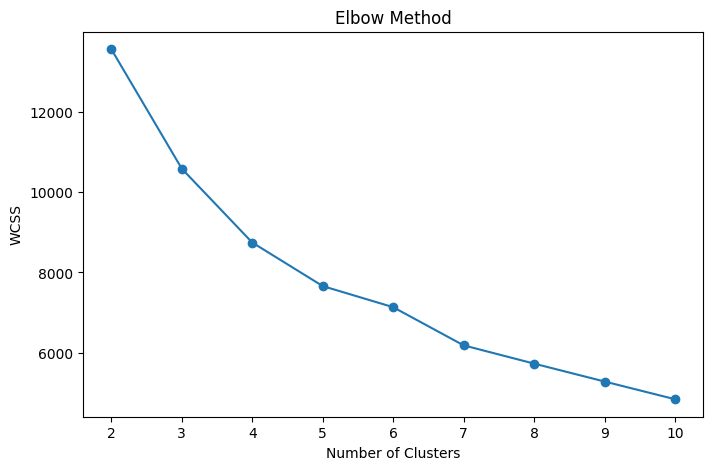


Model Comparison Results:
                                       Silhouette Davies_Bouldin
KMeans                                   0.287068       1.139388
Hierarchical                             0.259631       1.082026
DBSCAN        Not valid (single cluster or noise)      Not valid
GMM                                      0.105238       2.920742

Model Evaluation Completed Successfully.


In [1]:
# ==========================================
# CLUSTER MODEL COMPARISON & OPTIMIZATION
# ==========================================

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# -------------------------------
# 2. Load RFM Data
# -------------------------------
rfm = pd.read_csv("../data/processed/rfm_data.csv", index_col=0)

# Scale Features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# ==========================================
# 3. ELBOW METHOD (For KMeans)
# ==========================================

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ==========================================
# 4. TRAIN MODELS WITH k = 4 (Adjust if needed)
# ==========================================

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_scaled)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=4)
hier_labels = hierarchical.fit_predict(rfm_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(rfm_scaled)

# GMM
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(rfm_scaled)

# ==========================================
# 5. EVALUATION METRICS
# ==========================================

results = {}

# KMeans
results['KMeans'] = {
    "Silhouette": silhouette_score(rfm_scaled, kmeans_labels),
    "Davies_Bouldin": davies_bouldin_score(rfm_scaled, kmeans_labels)
}

# Hierarchical
results['Hierarchical'] = {
    "Silhouette": silhouette_score(rfm_scaled, hier_labels),
    "Davies_Bouldin": davies_bouldin_score(rfm_scaled, hier_labels)
}

# DBSCAN (Check if more than 1 cluster)
if len(set(dbscan_labels)) > 1 and -1 not in set(dbscan_labels):
    results['DBSCAN'] = {
        "Silhouette": silhouette_score(rfm_scaled, dbscan_labels),
        "Davies_Bouldin": davies_bouldin_score(rfm_scaled, dbscan_labels)
    }
else:
    results['DBSCAN'] = {
        "Silhouette": "Not valid (single cluster or noise)",
        "Davies_Bouldin": "Not valid"
    }

# GMM
results['GMM'] = {
    "Silhouette": silhouette_score(rfm_scaled, gmm_labels),
    "Davies_Bouldin": davies_bouldin_score(rfm_scaled, gmm_labels)
}

# ==========================================
# 6. DISPLAY RESULTS
# ==========================================

results_df = pd.DataFrame(results).T
print("\nModel Comparison Results:")
print(results_df)

# ==========================================
# 7. Save Results
# ==========================================

results_df.to_csv("../results/model_comparison_metrics.csv")

print("\nModel Evaluation Completed Successfully.")